# KAN Activation Functions Comparison (CIFAR-10)

Compare three KAN activation variants on CIFAR-10:
- **B-Spline** - Original KAN using B-spline basis
- **RBF** - Radial Basis Functions (Gaussian kernels)
- **Wavelet** - Mexican Hat or Morlet wavelets

Architectures tested:
- **Small Conv** - Lightweight convolutional model
- **Medium MLP** - KAN conv + standard MLP

**Warning** : Some of the numerical values may differ slightly between the report and the current notebook, that is because we made a clean run on the notebook and we did not set all the random seeds. However, the result difference are always very small and don't change the conclusions and observations we had.

In [7]:
import os
import sys
!git clone https://github.com/mathispernin/ConvKANs.git
%cd ConvKANs
current_dir = os.getcwd()
models_dir = os.path.join(current_dir, 'models')
if models_dir not in sys.path:
    sys.path.append(models_dir)

Cloning into 'ConvKANs'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 78 (delta 13), reused 16 (delta 7), pack-reused 50 (from 2)
Receiving objects: 100% (78/78), 60.20 MiB | 40.03 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/kaggle/working/ConvKANs/ConvKANs


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [9]:
def get_cifar_loaders(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    # Download data to a temp folder
    train_set = datasets.CIFAR10(root='./data_cifar', train=True, download=True, transform=transform)
    test_set = datasets.CIFAR10(root='./data_cifar', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader
train_loader, test_loader = get_cifar_loaders()

100%|██████████| 170M/170M [00:03<00:00, 47.2MB/s] 


In [10]:
from utils import get_cifar10, build_model, count_parameters
from trainer import Trainer
from configs import EXPERIMENTS

In [11]:
# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [12]:
TRAINING = {
    'batch_size': 128,
    'epochs': 15,
    'lr': 1e-3,
    'weight_decay': 1e-5,
}

## 1. Load Data

In [13]:
train_loader, test_loader = get_cifar10(
    batch_size=TRAINING['batch_size'],
    n_train=20000,
    n_test=2000
)

Loaded CIFAR-10 with 20000 training samples and 2000 test samples.


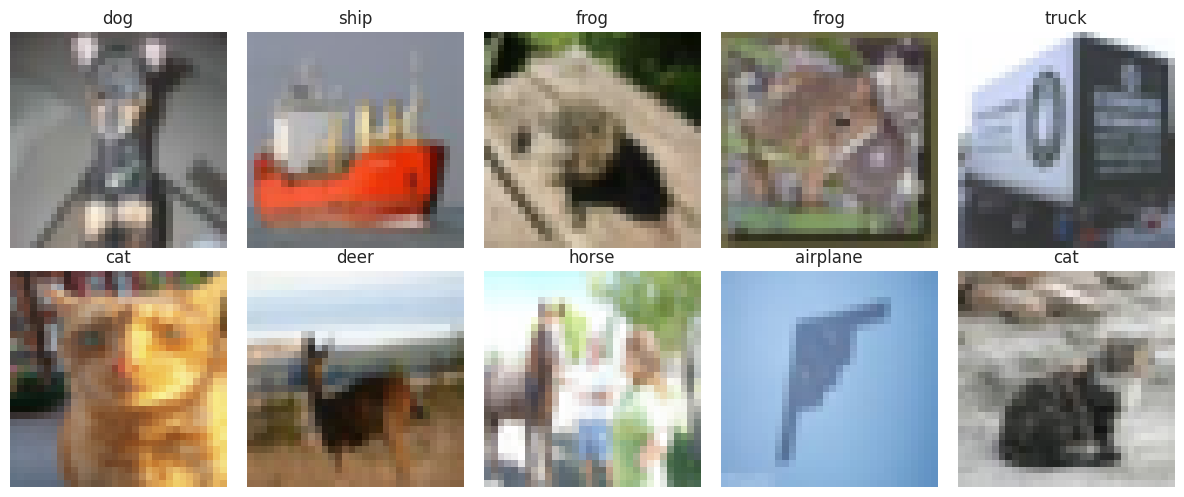

In [14]:
# Visualize samples
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_loader.dataset[i]
    # img: Tensor with shape [C,H,W] for CIFAR
    if img.ndim == 3 and img.shape[0] == 1:
        ax.imshow(img.squeeze(), cmap='gray')
    else:
        # unnormalize for display if necessary (images are normalized in loader)
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = np.clip((img_disp * np.array([0.2470, 0.2435, 0.2616])) + np.array([0.4914, 0.4822, 0.4465]), 0, 1)
        ax.imshow(img_disp)
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Standard CNN

In [15]:
import torch
import torch.nn as nn

class CIFAR10_CNNEquivalent_Small(nn.Module):
    """
    CIFAR-10 native (3x32x32), equivalent structure to:
      Conv (3 -> 5, 3x3, valid)
      Conv (5 -> 5, 3x3, valid)
      MaxPool (2x2)
      Flatten
      Linear (980 -> 10)   # 5 * 14 * 14
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 5, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(5, 5, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc    = nn.Linear(980, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)


In [16]:
import time
import torch
import torch.nn as nn

def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += bs

    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += bs

    return total_loss / total_n, total_correct / total_n

def fit(model, train_loader, test_loader, epochs=20, lr=1e-3, weight_decay=1e-4, device="cuda"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = eval_one_epoch(model, test_loader, criterion, device)

        dt = time.time() - t0
        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"test loss {te_loss:.4f} acc {te_acc:.4f} | "
            f"{dt:.1f}s"
        )


In [17]:
from utils import get_cifar10

train_loader, test_loader = get_cifar10(
    batch_size=128,
    n_train=20000,  # or smaller for quick tests
    n_test=2000,
)

Loaded CIFAR-10 with 20000 training samples and 2000 test samples.


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CIFAR10_CNNEquivalent_Small(num_classes=10)

fit(
    model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
)

Epoch 001/20 | train loss 1.8673 acc 0.3461 | test loss 1.7006 acc 0.4115 | 6.8s
Epoch 002/20 | train loss 1.6419 acc 0.4343 | test loss 1.5976 acc 0.4455 | 5.8s
Epoch 003/20 | train loss 1.5494 acc 0.4607 | test loss 1.5578 acc 0.4520 | 5.9s
Epoch 004/20 | train loss 1.4983 acc 0.4792 | test loss 1.5273 acc 0.4715 | 6.0s
Epoch 005/20 | train loss 1.4533 acc 0.4964 | test loss 1.5350 acc 0.4610 | 6.0s
Epoch 006/20 | train loss 1.4140 acc 0.5115 | test loss 1.4796 acc 0.4970 | 5.8s
Epoch 007/20 | train loss 1.3729 acc 0.5240 | test loss 1.4836 acc 0.4900 | 5.9s
Epoch 008/20 | train loss 1.3444 acc 0.5361 | test loss 1.4601 acc 0.4955 | 5.8s
Epoch 009/20 | train loss 1.3195 acc 0.5423 | test loss 1.4461 acc 0.5070 | 6.0s
Epoch 010/20 | train loss 1.3013 acc 0.5452 | test loss 1.4410 acc 0.5015 | 5.8s
Epoch 011/20 | train loss 1.2835 acc 0.5562 | test loss 1.4353 acc 0.5020 | 5.8s
Epoch 012/20 | train loss 1.2701 acc 0.5586 | test loss 1.4442 acc 0.4985 | 5.9s
Epoch 013/20 | train loss 1.

In [19]:
count_parameters(model)

10180

## 2. Visualize Activation Functions

In [20]:
from models.KANLinear import KANLinear
from models.RBFLinear import RBFLinear
from models.WavLinear import WavLinear
from configs import BSPLINE, RBF, WAVELET

In [21]:
# Sample input
x = torch.linspace(-2, 2, 1000).unsqueeze(0).unsqueeze(-1)

# Create layers
bspline = KANLinear(1, 1, **BSPLINE)
rbf = RBFLinear(1, 1, **RBF)
wavelet = WavLinear(1, 1, **WAVELET)

# Compute outputs
with torch.no_grad():
    y_bspline = bspline(x).squeeze()
    y_rbf = rbf(x).squeeze()
    y_wavelet = wavelet(x).squeeze()

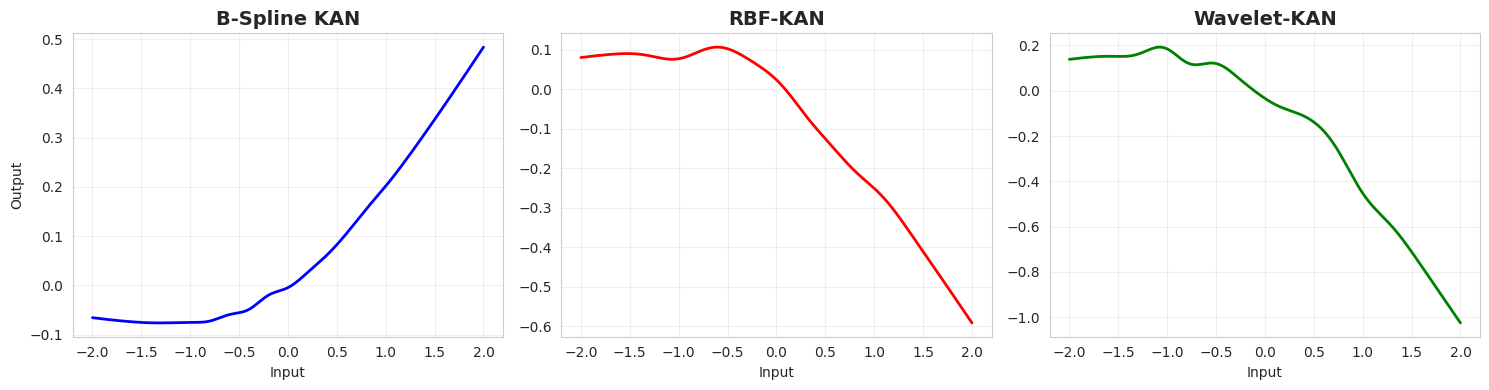

In [22]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_np = x.squeeze().numpy()

axes[0].plot(x_np, y_bspline.numpy(), 'b-', linewidth=2)
axes[0].set_title('B-Spline KAN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_np, y_rbf.numpy(), 'r-', linewidth=2)
axes[1].set_title('RBF-KAN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Input')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_np, y_wavelet.numpy(), 'g-', linewidth=2)
axes[2].set_title('Wavelet-KAN', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Input')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Run Experiments

Train all model variants and collect results.

In [23]:
# Select experiments to run (modify as needed)
experiments_to_run = ['small_bspline', 'small_rbf', 'small_wavelet', 'medium_bspline', 'medium_rbf', 'medium_wavelet']

results = {}

# CIFAR input settings
INPUT_PARAMS = {
    'in_channels': 3,
    'input_size': (32, 32),
    'num_classes': 10
}

for exp_name in experiments_to_run:
    exp_config = EXPERIMENTS[exp_name]
    
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_config['name']}")
    print(f"{'='*60}")
    # Move model to device before forward check
    
    # Build model (pass CIFAR input params)
    model = build_model(
        architecture=exp_config['architecture'],
        activation=exp_config['activation'],
        config=exp_config['config'],
        in_channels=INPUT_PARAMS['in_channels'],
        input_size=INPUT_PARAMS['input_size'],
        num_classes=INPUT_PARAMS['num_classes']
    )
    model = model.to(device)
    _test_x = torch.randn(2, 3, *(32,32)).to(device)
    _out = model(_test_x)
    print(f"Parameters: {count_parameters(model):,}")

    # Quick forward-shape sanity check
    try:
        _test_x = torch.randn(2, INPUT_PARAMS['in_channels'], *INPUT_PARAMS['input_size']).to(device)
        _out = model(_test_x)
        print("Forward check output shape:", _out.shape)
    except AssertionError as e:
        print("Forward check failed:", e)
        raise
    
    # Create trainer
    trainer = Trainer(
        model=model,
        device=device,
        lr=TRAINING['lr'],
        weight_decay=TRAINING['weight_decay'],
        reg_lambda=0.0,
        epochs=TRAINING['epochs']
    )
    
    # Train
    history = trainer.fit(
        train_loader=train_loader,
        val_loader=test_loader,
        epochs=TRAINING['epochs'],
        verbose=True
    )
    
    # Store results
    results[exp_name] = {
        'config': exp_config,
        'history': history,
        'metrics': trainer.get_final_metrics(),
        'num_params': count_parameters(model)
    }
    
    # Save checkpoint
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': exp_config,
        'history': history,
    }, f'./results/{exp_name}_gs=10.pt') # change the grid size in filename if modified

print("\n✓ All experiments completed!")


Experiment: KKAN Small - B-Spline
Parameters: 32,400
Forward check output shape: torch.Size([2, 10])


Epoch 1/15 | Time: 44.99s | Train Loss: 2.0068 | Train Acc: 28.08% | Val Acc: 37.30% | F1: 0.3612


Epoch 2/15 | Time: 44.50s | Train Loss: 1.6460 | Train Acc: 41.41% | Val Acc: 42.35% | F1: 0.4155


Epoch 3/15 | Time: 44.51s | Train Loss: 1.4907 | Train Acc: 46.98% | Val Acc: 46.75% | F1: 0.4655


Epoch 4/15 | Time: 44.53s | Train Loss: 1.4110 | Train Acc: 49.99% | Val Acc: 47.95% | F1: 0.4739


...

Epoch 11/15 | Time: 34.97s | Train Loss: 1.1381 | Train Acc: 59.48% | Val Acc: 52.35% | F1: 0.5194


Epoch 12/15 | Time: 34.67s | Train Loss: 1.1243 | Train Acc: 59.91% | Val Acc: 52.30% | F1: 0.5193


Epoch 13/15 | Time: 34.72s | Train Loss: 1.1165 | Train Acc: 60.34% | Val Acc: 52.00% | F1: 0.5166


Epoch 14/15 | Time: 34.89s | Train Loss: 1.1105 | Train Acc: 60.63% | Val Acc: 52.65% | F1: 0.5237


Epoch 15/15 | Time: 34.72s | Train Loss: 1.1083 | Train Acc: 60.87% | Val Acc: 52.60% | F1: 0.5232

✓ All experiments completed!


## 4. Visualize Results

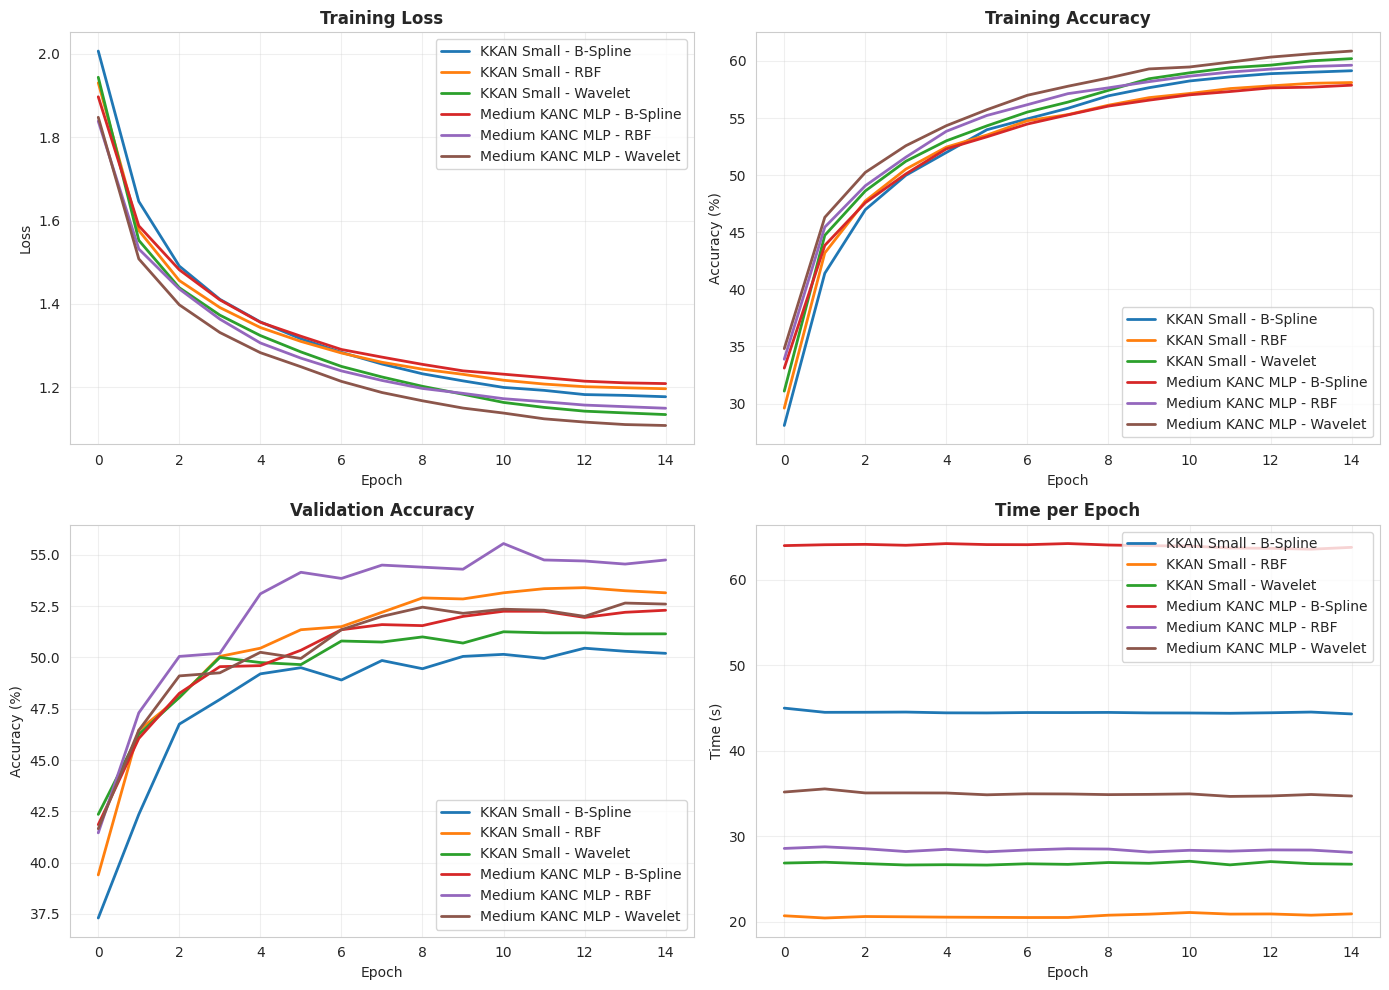

In [24]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for exp_name, result in results.items():
    history = result['history']
    label = result['config']['name']
    
    axes[0, 0].plot(history['train_loss'], label=label, linewidth=2)
    axes[0, 1].plot(history['train_acc'], label=label, linewidth=2)
    axes[1, 0].plot(history['val_acc'], label=label, linewidth=2)
    axes[1, 1].plot(history['epoch_time'], label=label, linewidth=2)

axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Time per Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/training_curves_gs=10.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Table

In [25]:
import pandas as pd

summary_data = []
for exp_name, result in results.items():
    metrics = result['metrics']
    summary_data.append({
        'Model': result['config']['name'],
        'Activation': result['config']['activation'].upper(),
        'Parameters': f"{result['num_params']:,}",
        'Accuracy (%)': f"{metrics['accuracy']:.2f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Time/Epoch (s)': f"{metrics['avg_epoch_time']:.2f}"
    })

df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("RESULTS SUMMARY")
print("="*100)
print(df.to_string(index=False))
print("="*100)

# Save to CSV
df.to_csv('./results/summary_gs=10.csv', index=False)
print("\n✓ Summary saved to results/summary_gs=10.csv")


RESULTS SUMMARY
                     Model Activation Parameters Accuracy (%) F1-Score Precision Recall Time/Epoch (s)
     KKAN Small - B-Spline     SPLINE     32,400        50.20   0.4981    0.4968 0.5020          44.49
          KKAN Small - RBF        RBF     31,320        53.15   0.5272    0.5257 0.5315          20.73
      KKAN Small - Wavelet    WAVELET     36,720        51.15   0.5070    0.5048 0.5115          26.82
Medium KANC MLP - B-Spline     SPLINE     12,385        52.30   0.5206    0.5195 0.5230          63.98
     Medium KANC MLP - RBF        RBF     16,480        54.75   0.5452    0.5447 0.5475          28.40
 Medium KANC MLP - Wavelet    WAVELET     22,330        52.60   0.5232    0.5222 0.5260          34.97

✓ Summary saved to results/summary_gs=10.csv


## 6. Compare Time

Direct comparison between time per epoch.

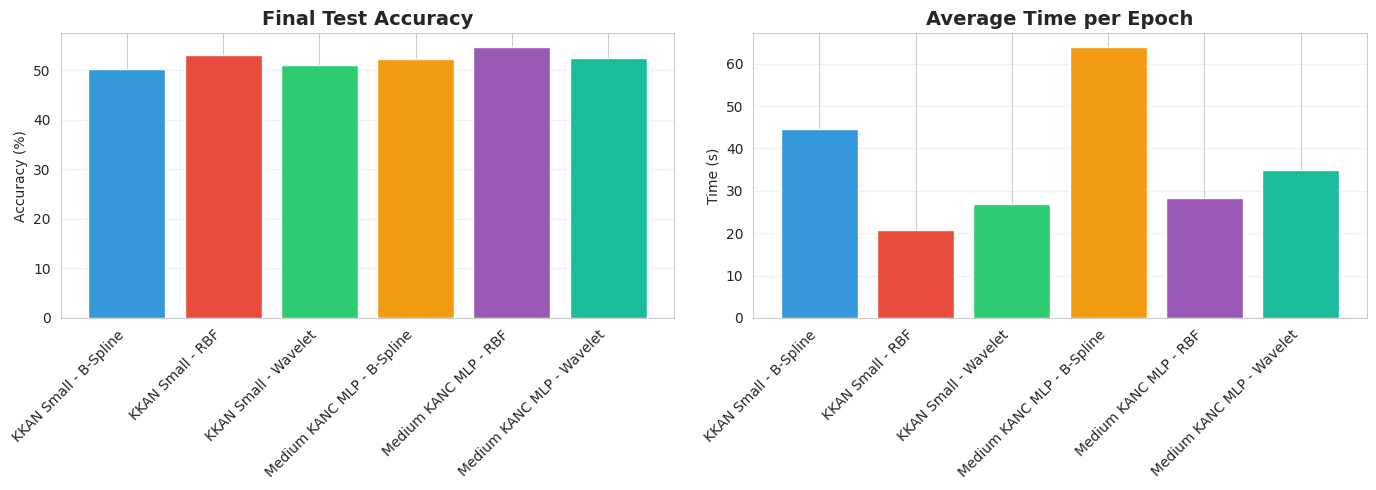

In [27]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [r['config']['name'] for r in results.values()]
accuracies = [r['metrics']['accuracy'] for r in results.values()]
times = [r['metrics']['avg_epoch_time'] for r in results.values()]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

axes[0].bar(range(len(models)), accuracies, color=colors[:len(models)])
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Final Test Accuracy', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(models)), times, color=colors[:len(models)])
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Average Time per Epoch', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./results/comparison_gs=10.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export Results

Save all results for later analysis.

In [28]:
import json

# Prepare export data
export_data = {}
for exp_name, result in results.items():
    export_data[exp_name] = {
        'name': result['config']['name'],
        'architecture': result['config']['architecture'],
        'activation': result['config']['activation'],
        'parameters': result['num_params'],
        'final_metrics': result['metrics'],
        'history': {
            'train_loss': [float(x) for x in result['history']['train_loss']],
            'train_acc': [float(x) for x in result['history']['train_acc']],
            'val_acc': [float(x) for x in result['history']['val_acc']],
            'val_f1': [float(x) for x in result['history']['val_f1']],
        }
    }

# Save JSON
with open('./results/all_results_gs=10.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("✓ Results exported to results/all_results_gs=10.json")

✓ Results exported to results/all_results_gs=10.json


## Expermiment Noise Injection


Starting Noise Robustness Test (Reloading Models)

--- Loading and Testing: small_bspline ---
  Sigma 0.0: 50.20%
  Sigma 0.1: 42.00%
  Sigma 0.2: 42.05%
  Sigma 0.3: 39.90%
  Sigma 0.4: 35.85%
  Sigma 0.5: 34.50%

--- Loading and Testing: small_rbf ---
  Sigma 0.0: 53.15%
  Sigma 0.1: 42.75%
  Sigma 0.2: 40.35%
  Sigma 0.3: 35.45%
  Sigma 0.4: 30.55%
  Sigma 0.5: 26.70%

--- Loading and Testing: small_wavelet ---
  Sigma 0.0: 51.15%
  Sigma 0.1: 39.40%
  Sigma 0.2: 36.50%
  Sigma 0.3: 32.45%
  Sigma 0.4: 29.55%
  Sigma 0.5: 25.45%

--- Loading and Testing: medium_bspline ---
  Sigma 0.0: 52.30%
  Sigma 0.1: 43.45%
  Sigma 0.2: 40.60%
  Sigma 0.3: 37.05%
  Sigma 0.4: 33.80%
  Sigma 0.5: 30.55%

--- Loading and Testing: medium_rbf ---
  Sigma 0.0: 54.75%
  Sigma 0.1: 47.60%
  Sigma 0.2: 43.90%
  Sigma 0.3: 38.70%
  Sigma 0.4: 34.20%
  Sigma 0.5: 29.25%

--- Loading and Testing: medium_wavelet ---
  Sigma 0.0: 52.60%
  Sigma 0.1: 36.10%
  Sigma 0.2: 31.30%
  Sigma 0.3: 27.00%
  Sigma 0.

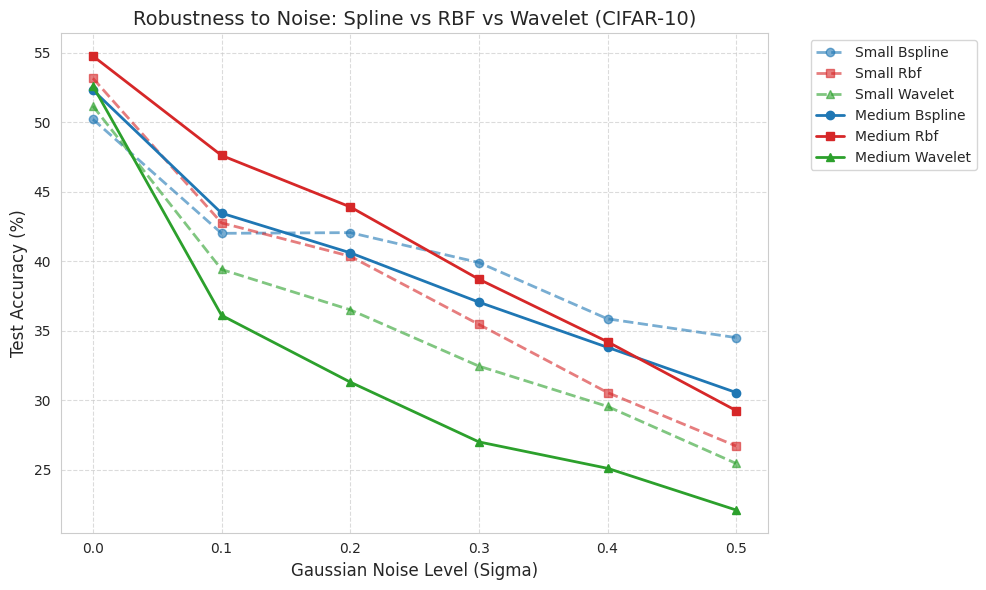

Data saved to: results/cifar10/robustness_data.json


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import json
import os

# --- 1. NOISE INJECTION FUNCTION ---
def evaluate_with_noise(model, test_loader, device, noise_sigma):
    """
    Evaluates the model on the test set with added Gaussian noise.
    noise_sigma : Standard deviation of the added noise (0.0 = no noise)
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            # Inject noise
            if noise_sigma > 0:
                noise = torch.randn_like(data) * noise_sigma
                data = data + noise
                # Clamp to keep valid image range [-1, 1] for normalized data
                data = torch.clamp(data, -1.0, 1.0)
            
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
            
    return 100. * correct / total

# --- 2. CONFIGURATION ---
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
robustness_results = {}

print(f"\n{'='*60}")
print("Starting Noise Robustness Test (Reloading Models)")
print(f"{'='*60}")

# --- 3. EXECUTION LOOP ---
# We iterate over the experiment names you defined in your previous cell
for exp_name in experiments_to_run:
    print(f"\n--- Loading and Testing: {exp_name} ---")
    
    # 3.1 Rebuild the model structure using your existing EXPERIMENTS dict
    exp_config = EXPERIMENTS[exp_name]
    model = build_model(
        architecture=exp_config['architecture'],
        activation=exp_config['activation'],
        config=exp_config['config'],
        in_channels=INPUT_PARAMS['in_channels'],
        input_size=INPUT_PARAMS['input_size'],
        num_classes=INPUT_PARAMS['num_classes']
    )
    
    # 3.2 Load the weights from the file you just saved
    checkpoint_path = f'./results/{exp_name}_gs=10.pt'
    if not os.path.exists(checkpoint_path):
        print(f"Warning: Checkpoint not found at {checkpoint_path}, skipping.")
        continue
        
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    
    # 3.3 Run the noise evaluation
    model_accuracies = []
    for noise in noise_levels:
        acc = evaluate_with_noise(model, test_loader, device, noise)
        model_accuracies.append(acc)
        print(f"  Sigma {noise}: {acc:.2f}%")
        
    robustness_results[exp_name] = model_accuracies
    
    # Clear memory
    del model
    torch.cuda.empty_cache()

# --- 4. VISUALIZATION AND SAVING ---
plt.figure(figsize=(10, 6))

# Updated styles to match your lowercase keys ('bspline', 'rbf', 'wavelet')
styles = {
    'bspline': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},  # Blue
    'rbf':     {'color': '#d62728', 'marker': 's', 'linestyle': '-'},  # Red
    'wavelet': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-'}   # Green
}

for name, accs in robustness_results.items():
    # Determine style based on name substring
    if 'bspline' in name: style = styles['bspline']
    elif 'rbf' in name:   style = styles['rbf']
    elif 'wavelet' in name: style = styles['wavelet']
    else: style = {'color': 'black', 'marker': 'x', 'linestyle': '--'}
    
    # Differentiate Small vs Medium by line style/transparency
    # Assuming 'medium' or 'small' is in the exp_name string
    is_medium = 'medium' in name
    linestyle = '-' if is_medium else '--'
    alpha = 1.0 if is_medium else 0.6
    label_name = name.replace('_', ' ').title() # Make label pretty (e.g. "Small Bspline")
    
    plt.plot(noise_levels, accs, 
             label=label_name, 
             marker=style['marker'], 
             color=style['color'], 
             linestyle=linestyle,
             alpha=alpha,
             linewidth=2)

plt.title("Robustness to Noise: Spline vs RBF vs Wavelet (CIFAR-10)", fontsize=14)
plt.xlabel("Gaussian Noise Level (Sigma)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save plot
os.makedirs('results/cifar10', exist_ok=True)
plot_path = 'results/cifar10/robustness_noise_plot.png'
plt.savefig(plot_path, dpi=300)
print(f"\nGraph saved to: {plot_path}")
plt.show()

# Save raw data
data_path = 'results/cifar10/robustness_data.json'
with open(data_path, 'w') as f:
    json.dump(robustness_results, f)
print(f"Data saved to: {data_path}")

## Batch Norm Training

In [29]:
from utils import build_model
# Select experiments to run (modify as needed)
experiments_to_run = ['small_bspline', 'small_rbf', 'small_wavelet', 'medium_bspline', 'medium_rbf', 'medium_wavelet']

results = {}

# CIFAR input settings
INPUT_PARAMS = {
    'in_channels': 3,
    'input_size': (32, 32),
    'num_classes': 10
}

for exp_name in experiments_to_run:
    exp_config = EXPERIMENTS[exp_name]
    
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_config['name']}")
    print(f"{'='*60}")
    # Move model to device before forward check
    
    # Build model (pass CIFAR input params)
    model = build_model(
        architecture=exp_config['architecture'],
        activation=exp_config['activation'],
        config=exp_config['config'],
        in_channels=INPUT_PARAMS['in_channels'],
        input_size=INPUT_PARAMS['input_size'],
        num_classes=INPUT_PARAMS['num_classes'],
        use_batchnorm=True,
    )
    model = model.to(device)
    _test_x = torch.randn(2, 3, *(32,32)).to(device)
    _out = model(_test_x)
    print(f"Parameters: {count_parameters(model):,}")

    # Quick forward-shape sanity check
    try:
        _test_x = torch.randn(2, INPUT_PARAMS['in_channels'], *INPUT_PARAMS['input_size']).to(device)
        _out = model(_test_x)
        print("Forward check output shape:", _out.shape)
    except AssertionError as e:
        print("Forward check failed:", e)
        raise
    
    # Create trainer
    trainer = Trainer(
        model=model,
        device=device,
        lr=TRAINING['lr'],
        weight_decay=TRAINING['weight_decay'],
        reg_lambda=0.0,
        epochs=TRAINING['epochs']
    )
    
    # Train
    history = trainer.fit(
        train_loader=train_loader,
        val_loader=test_loader,
        epochs=TRAINING['epochs'],
        verbose=True
    )
    
    # Store results
    results[exp_name] = {
        'config': exp_config,
        'history': history,
        'metrics': trainer.get_final_metrics(),
        'num_params': count_parameters(model)
    }
    
    # Save checkpoint
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': exp_config,
        'history': history,
    }, f'./results/{exp_name}_gs=10.pt') # change the grid size in filename if modified

print("\n✓ All experiments completed!")


Experiment: KKAN Small - B-Spline
Parameters: 32,420
Forward check output shape: torch.Size([2, 10])


Epoch 1/15 | Time: 44.36s | Train Loss: 1.9106 | Train Acc: 30.91% | Val Acc: 40.30% | F1: 0.3879


Epoch 2/15 | Time: 44.27s | Train Loss: 1.5321 | Train Acc: 45.11% | Val Acc: 46.65% | F1: 0.4564


Epoch 3/15 | Time: 44.21s | Train Loss: 1.4021 | Train Acc: 50.11% | Val Acc: 49.10% | F1: 0.4806


Epoch 4/15 | Time: 44.20s | Train Loss: 1.3353 | Train Acc: 52.92% | Val Acc: 49.85% | F1: 0.4925


...

Epoch 11/15 | Time: 35.56s | Train Loss: 1.1614 | Train Acc: 59.23% | Val Acc: 52.35% | F1: 0.5203


Epoch 12/15 | Time: 35.57s | Train Loss: 1.1499 | Train Acc: 59.48% | Val Acc: 52.65% | F1: 0.5228


Epoch 13/15 | Time: 35.67s | Train Loss: 1.1374 | Train Acc: 60.23% | Val Acc: 52.65% | F1: 0.5242


Epoch 14/15 | Time: 35.22s | Train Loss: 1.1379 | Train Acc: 60.11% | Val Acc: 52.40% | F1: 0.5203


Epoch 15/15 | Time: 35.21s | Train Loss: 1.1313 | Train Acc: 60.48% | Val Acc: 52.85% | F1: 0.5248

✓ All experiments completed!


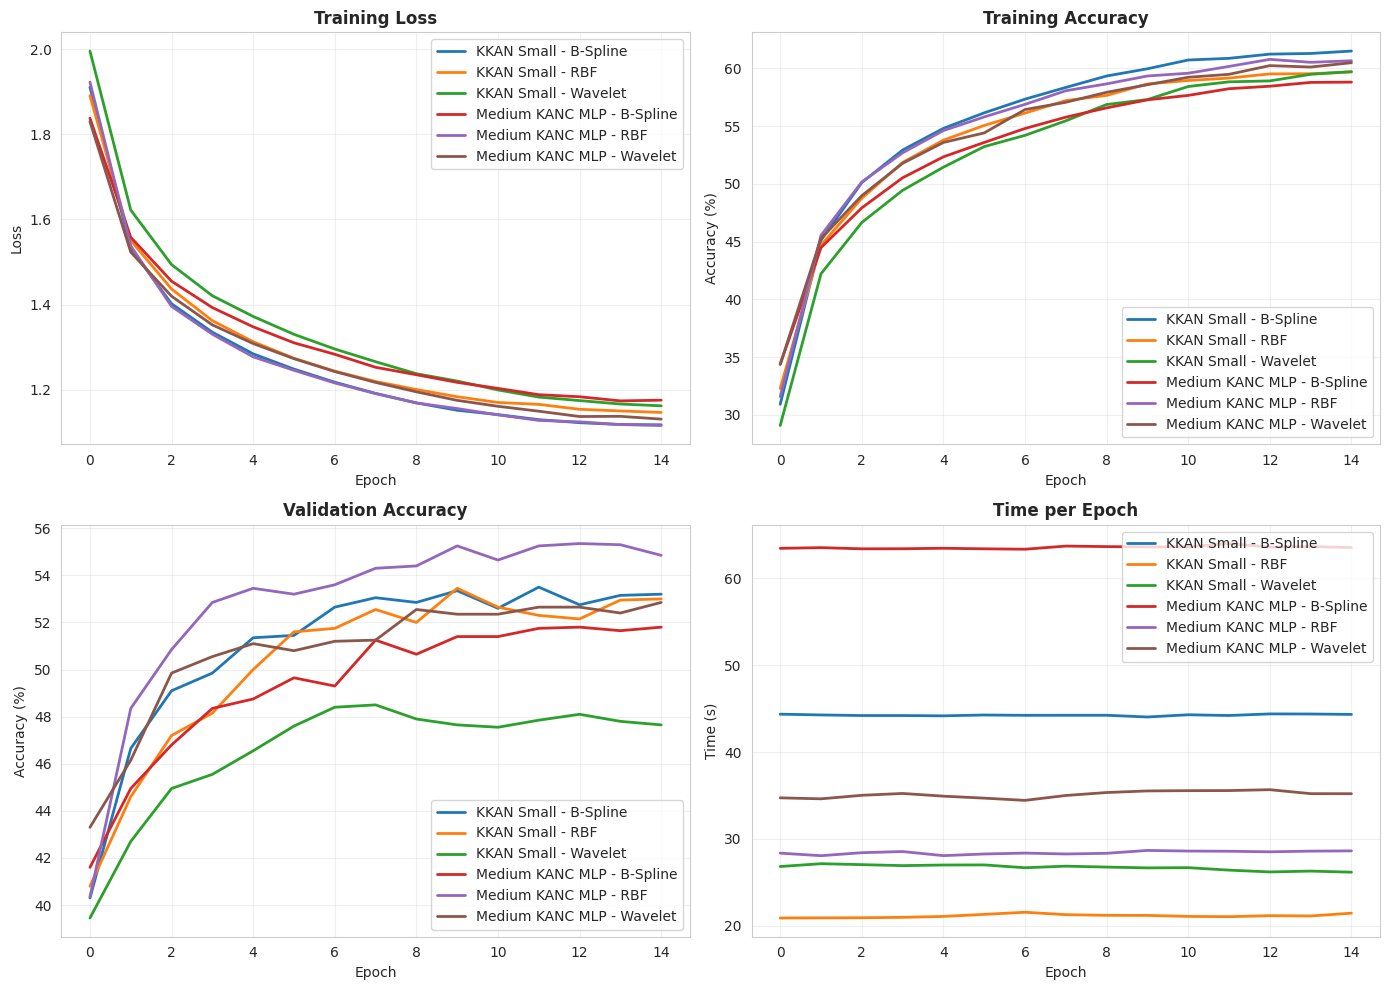

In [30]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for exp_name, result in results.items():
    history = result['history']
    label = result['config']['name']
    
    axes[0, 0].plot(history['train_loss'], label=label, linewidth=2)
    axes[0, 1].plot(history['train_acc'], label=label, linewidth=2)
    axes[1, 0].plot(history['val_acc'], label=label, linewidth=2)
    axes[1, 1].plot(history['epoch_time'], label=label, linewidth=2)

axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Time per Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/training_curves_gs=10.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import pandas as pd

summary_data = []
for exp_name, result in results.items():
    metrics = result['metrics']
    summary_data.append({
        'Model': result['config']['name'],
        'Activation': result['config']['activation'].upper(),
        'Parameters': f"{result['num_params']:,}",
        'Accuracy (%)': f"{metrics['accuracy']:.2f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Time/Epoch (s)': f"{metrics['avg_epoch_time']:.2f}"
    })

df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("RESULTS SUMMARY")
print("="*100)
print(df.to_string(index=False))
print("="*100)

# Save to CSV
df.to_csv('./results/summary_gs=10.csv', index=False)
print("\n✓ Summary saved to results/summary_gs=10.csv")


RESULTS SUMMARY
                     Model Activation Parameters Accuracy (%) F1-Score Precision Recall Time/Epoch (s)
     KKAN Small - B-Spline     SPLINE     32,420        53.20   0.5273    0.5262 0.5320          44.26
          KKAN Small - RBF        RBF     31,340        53.00   0.5251    0.5237 0.5300          21.16
      KKAN Small - Wavelet    WAVELET     36,740        47.65   0.4720    0.4707 0.4765          26.72
Medium KANC MLP - B-Spline     SPLINE     12,415        51.80   0.5149    0.5143 0.5180          63.55
     Medium KANC MLP - RBF        RBF     16,510        54.85   0.5457    0.5455 0.5485          28.43
 Medium KANC MLP - Wavelet    WAVELET     22,360        52.85   0.5248    0.5232 0.5285          35.12

✓ Summary saved to results/summary_gs=10.csv


## Experiment dataset size

In [ ]:
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch


DATASET_SIZES = [10_000, 5_000, 1_000, 100]

# Select experiments to run
experiments_to_run = [
    'small_bspline', 'small_rbf', 'small_wavelet',
    'medium_bspline', 'medium_rbf', 'medium_wavelet'
]

results = {}

# CIFAR input settings
INPUT_PARAMS = {
    'in_channels': 3,
    'input_size': (32, 32),
    'num_classes': 10
}

rng = np.random.default_rng(seed=42)
train_dataset = train_loader.dataset

for dataset_size in DATASET_SIZES:

    print(f"\n{'#'*70}")
    print(f"Running experiments with dataset size = {dataset_size}")
    print(f"{'#'*70}")

    indices = rng.choice(len(train_dataset), size=dataset_size, replace=False)
    small_train_dataset = Subset(train_dataset, indices)

    train_loader = DataLoader(
        small_train_dataset,
        batch_size=TRAINING['batch_size'],
        shuffle=True,
        num_workers=TRAINING.get('num_workers', 4),
        pin_memory=True
    )

    results[dataset_size] = {}

    for exp_name in experiments_to_run:
        exp_config = EXPERIMENTS[exp_name]

        print(f"\n{'='*60}")
        print(f"Experiment: {exp_config['name']} | N = {dataset_size}")
        print(f"{'='*60}")

        # Build model
        model = build_model(
            architecture=exp_config['architecture'],
            activation=exp_config['activation'],
            config=exp_config['config'],
            in_channels=INPUT_PARAMS['in_channels'],
            input_size=INPUT_PARAMS['input_size'],
            num_classes=INPUT_PARAMS['num_classes']
        ).to(device)

        print(f"Parameters: {count_parameters(model):,}")

        # Forward sanity check
        try:
            _test_x = torch.randn(
                2,
                INPUT_PARAMS['in_channels'],
                *INPUT_PARAMS['input_size']
            ).to(device)
            _out = model(_test_x)
            print("Forward check output shape:", _out.shape)
        except AssertionError as e:
            print("Forward check failed:", e)
            raise

        # Trainer
        trainer = Trainer(
            model=model,
            device=device,
            lr=TRAINING['lr'],
            weight_decay=TRAINING['weight_decay'],
            reg_lambda=0.0,
            epochs=TRAINING['epochs']
        )

        # Train
        history = trainer.fit(
            train_loader=train_loader,
            val_loader=test_loader,
            epochs=TRAINING['epochs'],
            verbose=True
        )

        # Store results
        results[dataset_size][exp_name] = {
            'config': exp_config,
            'history': history,
            'metrics': trainer.get_final_metrics(),
            'num_params': count_parameters(model)
        }

        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'config': exp_config,
                'history': history,
                'dataset_size': dataset_size
            },
            f'./results/{exp_name}_N={dataset_size}_gs=10.pt'
        )

print("\n✓ All experiments completed for all dataset sizes!")



######################################################################
Running experiments with dataset size = 10000
######################################################################

Experiment: KKAN Small - B-Spline | N = 10000
Parameters: 32,400
Forward check output shape: torch.Size([2, 10])


Epoch 1/15 | Time: 21.04s | Train Loss: 2.1268 | Train Acc: 22.84% | Val Acc: 31.20% | F1: 0.2912


Epoch 2/15 | Time: 21.04s | Train Loss: 1.8732 | Train Acc: 33.93% | Val Acc: 37.25% | F1: 0.3537


Epoch 3/15 | Time: 21.01s | Train Loss: 1.7272 | Train Acc: 39.65% | Val Acc: 40.20% | F1: 0.3896


Epoch 4/15 | Time: 21.03s | Train Loss: 1.6208 | Train Acc: 43.15% | Val Acc: 41.40% | F1: 0.4033


...

Epoch 11/15 | Time: 1.46s | Train Loss: 1.9051 | Train Acc: 37.00% | Val Acc: 18.65% | F1: 0.1476


Epoch 12/15 | Time: 1.45s | Train Loss: 1.8929 | Train Acc: 38.00% | Val Acc: 19.00% | F1: 0.1508


Epoch 13/15 | Time: 1.46s | Train Loss: 1.8847 | Train Acc: 39.00% | Val Acc: 19.15% | F1: 0.1525


Epoch 14/15 | Time: 1.45s | Train Loss: 1.8800 | Train Acc: 39.00% | Val Acc: 19.20% | F1: 0.1532


Epoch 15/15 | Time: 1.46s | Train Loss: 1.8779 | Train Acc: 39.00% | Val Acc: 19.20% | F1: 0.1532

✓ All experiments completed for all dataset sizes!
